# Financial Risk Intelligence Platform (FRIP)

## Executive report

### Purpose

This report translates the selected credit-risk model into portfolio metrics and an illustrative decision scenario. It supports analyst review and is not an automated credit-decisioning system.

> Run `04_modeling.ipynb` first. This report loads the exact saved model and recreates the same held-out test partition.


## Executive decision frame

This report is structured around three questions for a credit-risk stakeholder:

1. **Can the model rank default risk better than a manual single-factor rule?** Review ROC-AUC and average precision.
2. **What is the portfolio trade-off at a given risk threshold?** Review approval rate, default rate among approved applicants, and default capture.
3. **What controls are required before operational use?** Review the governance recommendations and limitations.

### What this report is — and is not

It is a decision-support view of an experimental model. It is not a production credit policy, a pricing engine, a fairness assessment, or an automated approval/decline system.


In [1]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "Raw"
PROCESSED_DATA_DIR = DATA_DIR / "Processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"

sns.set_theme(style="whitegrid", context="talk")


## Model and portfolio snapshot

In [2]:
metadata_path = MODELS_DIR / "best_model_metadata.json"
model_path = MODELS_DIR / "best_model.joblib"

if not metadata_path.exists() or not model_path.exists():
    raise FileNotFoundError("Run 04_modeling.ipynb before this report.")

metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
pipeline = joblib.load(model_path)

train = pd.read_csv(PROCESSED_DATA_DIR / "train_feature_engineered.csv")
target = train["TARGET"]
features = train.reindex(columns=metadata["feature_columns"]).replace([np.inf, -np.inf], np.nan)

_, X_test, _, y_test = train_test_split(
    features,
    target,
    test_size=metadata["test_size"],
    stratify=target,
    random_state=metadata["random_state"],
)

probabilities = pipeline.predict_proba(X_test)[:, 1]
portfolio_snapshot = pd.DataFrame(
    {
        "metric": ["Applications", "Model features", "Observed default rate", "Selected model"],
        "value": [
            f"{len(train):,}",
            len(metadata["feature_columns"]),
            f"{target.mean():.2%}",
            metadata["best_model"],
        ],
    }
)
portfolio_snapshot


,metric,value
0,Applications,"307,511"
1,Model features,116
2,Observed default rate,8.07%
3,Selected model,HistGradientBoosting


## Predictive performance

In [3]:
performance = pd.DataFrame(
    {
        "metric": ["ROC-AUC", "Average precision"],
        "value": [roc_auc_score(y_test, probabilities), average_precision_score(y_test, probabilities)],
    }
)
performance.style.format({"value": "{:.4f}"})


,metric,value
0,ROC-AUC,0.7630
1,Average precision,0.2498


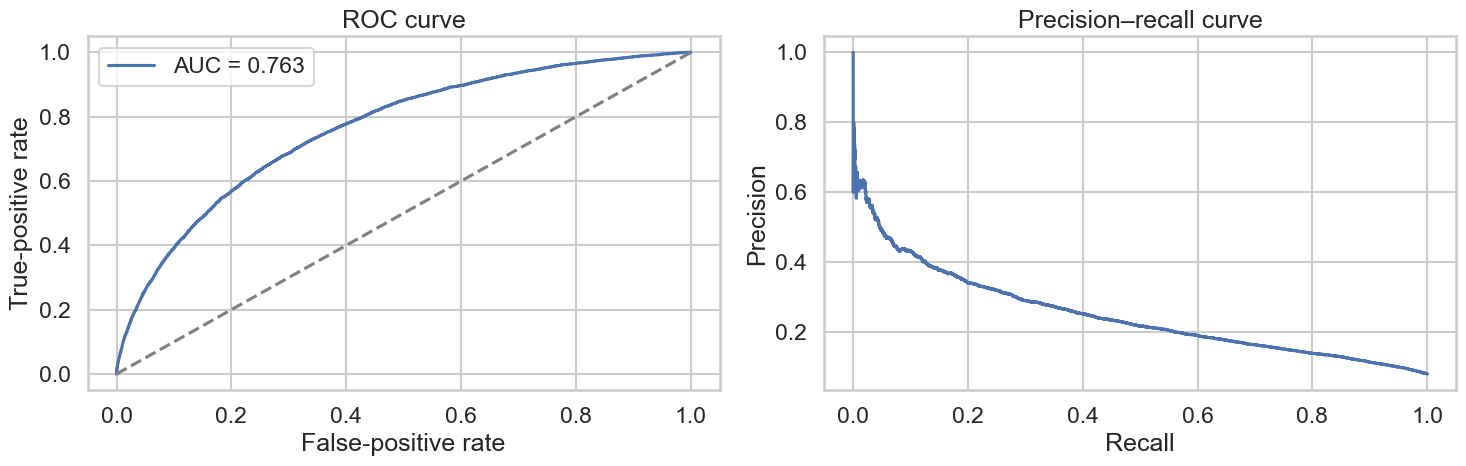

In [4]:
fpr, tpr, _ = roc_curve(y_test, probabilities)
precision, recall, _ = precision_recall_curve(y_test, probabilities)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, probabilities):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[0].set(title="ROC curve", xlabel="False-positive rate", ylabel="True-positive rate")
axes[0].legend()

axes[1].plot(recall, precision)
axes[1].set(title="Precision–recall curve", xlabel="Recall", ylabel="Precision")
plt.tight_layout()
plt.show()


## Illustrative decision scenario

The following scenario rejects applications whose predicted default probability is at least 0.50. This is a reporting example only; production thresholds must reflect expected loss, customer outcomes, fairness, and regulatory requirements.


In [5]:
policy_threshold = 0.50
approved = probabilities < policy_threshold
defaulted = y_test.to_numpy() == 1

scenario = pd.DataFrame(
    {
        "metric": [
            "Illustrative approval rate",
            "Observed default rate among approved",
            "Default capture rate among rejected",
        ],
        "value": [
            approved.mean(),
            defaulted[approved].mean() if approved.any() else np.nan,
            ((~approved & defaulted).sum() / defaulted.sum()) if defaulted.sum() else np.nan,
        ],
    }
)
scenario.style.format({"value": "{:.2%}"})


,metric,value
0,Illustrative approval rate,99.75%
1,Observed default rate among approved,7.94%
2,Default capture rate among rejected,1.95%


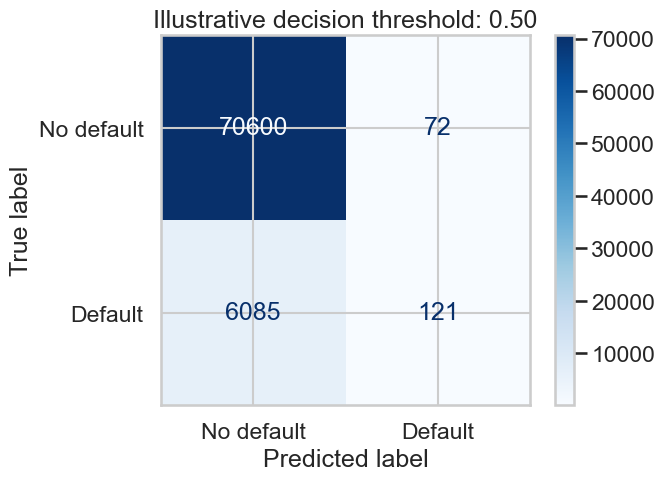

In [6]:
predictions = (probabilities >= policy_threshold).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=["No default", "Default"], cmap="Blues")
plt.title(f"Illustrative decision threshold: {policy_threshold:.2f}")
plt.show()


## Recommendations and controls

1. Use the model as a decision-support signal alongside analyst judgment and verified application data.
2. Set approval thresholds through an expected-loss and customer-outcome analysis, not AUC alone.
3. Validate calibration, fairness, stability, and drift before deployment and monitor them continuously.
4. Use Notebook 05 for portfolio-level and applicant-level SHAP explanations.

## Limitation

This educational project uses competition data. Its results are not sufficient for production lending, regulatory reporting, or automated adverse-action decisions.


## Management actions

| Priority | Recommended action | Expected outcome |
| --- | --- | --- |
| 1 | Agree risk appetite and expected-loss assumptions. | A defensible threshold and approval strategy. |
| 2 | Validate calibration, fairness, and stability on representative data. | Confidence that model scores are appropriate for the intended use. |
| 3 | Define human-review, exception, and customer-communication processes. | Accountable operational use. |
| 4 | Monitor performance and data drift after deployment. | Early detection of deteriorating model or portfolio behaviour. |
